In [1]:
import os
import cv2
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, RocCurveDisplay, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer,LabelEncoder, label_binarize
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.svm import LinearSVC

from tensorflow import keras 
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Model, Sequential, save_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.applications import DenseNet121
from sklearn.metrics import roc_curve, auc

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from keras.backend import clear_session
import os
import random
import numpy as np
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.utils import img_to_array ,load_img, array_to_img
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dropout, Flatten, Dense
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
import gc

In [4]:
# Définir les noms des classes
classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
label_map = {label: idx + 1 for idx, label in enumerate(classes)}

# Définir le chemin vers le dossier DATASET 
dataset_path = r"C:\Users\Lenovo\Desktop\DATASET\DATASET"  # ou 'dataset/train'


In [5]:
img_w, img_h = 128, 128
images = []
labels = []

# Chargement des images pour l'ensemble d'entraînement
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        try:
            img = Image.open(os.path.join(class_dir, img_name)).convert('RGB')
            img = img.resize((img_w, img_h))
            images.append(np.asarray(img))
            labels.append(label)
        except UnidentifiedImageError:
            pass

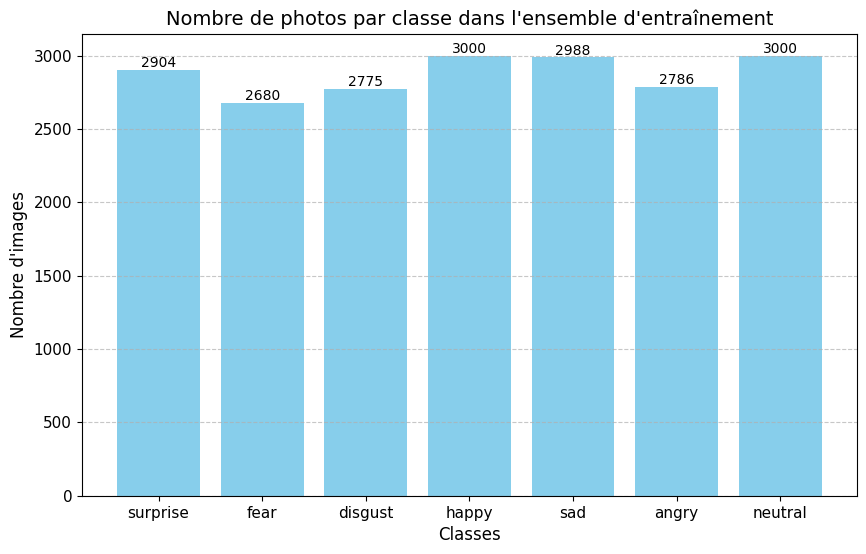

In [8]:
# Compter le nombre d'images par classe
counts = [0] * len(classes)
for label in labels:
    counts[label] += 1

# Créer l'histogramme
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color='skyblue')

# Ajouter les valeurs exactes au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             '%d' % int(height),
             ha='center', va='bottom')

# Ajouter des titres et labels
plt.title('Nombre de photos par classe dans l\'ensemble d\'entraînement', fontsize=14)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Nombre d\'images', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Afficher une grille pour une meilleure lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [9]:
X = np.array(images)  # Conversion en array
x = X.astype('float32')  # Normalisation
x /= 255

# Encodage des labels en one-hot
num_classes = len(classes)
labels = keras.utils.to_categorical(labels, num_classes)

In [10]:
# Étape 1 : on garde 30% pour val + test
x_temp, x_train, y_temp, y_train = train_test_split(
    x, labels, test_size=0.7, random_state=5, stratify=labels)

# Étape 2 : on divise les 30% restants en 15% val et 15% test
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=5, stratify=y_temp)

In [11]:
print('Number of train: {}'.format(len(x_train)))
print('Number of validation: {}'.format(len(x_val)))
print('Number of test: {}'.format(len(x_test)))

Number of train: 14094
Number of validation: 3019
Number of test: 3020


In [12]:
#data augmentation for DenseNet
datagen = ImageDataGenerator(
    rotation_range=20,             
    width_shift_range=0.1,         
    height_shift_range=0.1,  
    vertical_flip=False,               
    horizontal_flip=True, 
    fill_mode='nearest'
)

# Create the generator for training
train_generator = datagen.flow(x_train, y_train, batch_size=64)

### DenseNet model 

In [13]:
# Load the DenseNet model pre-trained on ImageNet
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(x_test[0].shape))

# Add custom layers on top of DenseNet
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
output_tensor  = Dense(len(classes), activation='softmax')(x)

DenseNet_model = Model(inputs=base_model.input, outputs=output_tensor)

# Freeze base layers of DenseNet
for layer in base_model.layers:
    layer.trainable = False

DenseNet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
DenseNet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 134, 134, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1/conv[0][0]']         

In [15]:
# Train the DenseNet model
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_delta=0.0001, verbose=1) 
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)  
checkpoint = ModelCheckpoint(filepath='best_DenseNetModel.keras', monitor='val_accuracy', save_best_only=True, verbose=1) 

DenseNet_History = DenseNet_model.fit(
    train_generator, 
    epochs=40, 
    batch_size = 32,
    validation_data=(x_test, y_test), 
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Epoch 1/40
221/221 [==============================] - ETA: 0s - loss: 1.0470 - accuracy: 0.6354
Epoch 1: val_accuracy improved from -inf to 0.67550, saving model to best_DenseNetModel.keras
221/221 [==============================] - 477s 2s/step - loss: 1.0470 - accuracy: 0.6354 - val_loss: 0.9133 - val_accuracy: 0.6755 - lr: 0.0010
Epoch 2/40
221/221 [==============================] - ETA: 0s - loss: 0.8747 - accuracy: 0.6827
Epoch 2: val_accuracy improved from 0.67550 to 0.70232, saving model to best_DenseNetModel.keras
221/221 [==============================] - 387s 2s/step - loss: 0.8747 - accuracy: 0.6827 - val_loss: 0.8194 - val_accuracy: 0.7023 - lr: 0.0010
Epoch 3/40
221/221 [==============================] - ETA: 0s - loss: 0.8261 - accuracy: 0.6993
Epoch 3: val_accuracy did not improve from 0.70232
221/221 [==============================] - 387s 2s/step - loss: 0.8261 - accuracy: 0.6993 - val_loss: 0.8494 - val_accuracy: 0.6874 - lr: 0.0010
Epoch 4/40
221/221 [===============

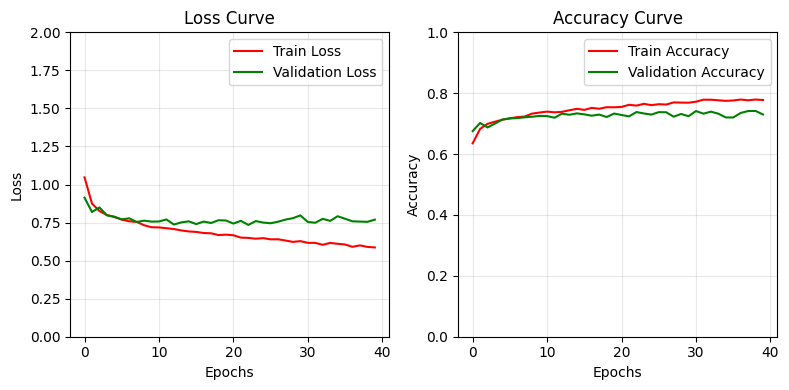

In [16]:
train_loss = DenseNet_History.history['loss']
val_loss = DenseNet_History.history['val_loss']
train_accuracy = DenseNet_History.history['accuracy']
val_accuracy = DenseNet_History.history['val_accuracy']

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(train_loss, label='Train Loss', color='red')
ax[0].plot(val_loss, label='Validation Loss', color='green')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].set_ylim([0, 2])
ax[0].grid(alpha=0.3)

ax[1].plot(train_accuracy, label='Train Accuracy', color='red')
ax[1].plot(val_accuracy, label='Validation Accuracy', color='green')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].set_ylim([0, 1])                                                                                                   
ax[1].grid(alpha=0.3)

# Ajuster l'espacement entre les sous-graphes
plt.tight_layout()
plt.show()

In [17]:
train_DenseNetresult = DenseNet_model.evaluate(x_train, y_train)
test_DenseNetresult = DenseNet_model.evaluate(x_test, y_test)

# Evaluate the CNN model
print("Train Loss: {:.2f}%".format(train_DenseNetresult[0] * 100))
print("Train Accuracy: {:.2f}%".format(train_DenseNetresult[1] * 100))

print("\nTest Loss: {:.2f}%".format(test_DenseNetresult[0] * 100))
print("Test Accuracy: {:.2f}%".format(test_DenseNetresult[1] * 100))

95/95 [==============================] - 87s 918ms/step - loss: 0.7693 - accuracy: 0.7301
Train Loss: 47.95%
Train Accuracy: 82.82%

Test Loss: 76.93%
Test Accuracy: 73.01%


In [18]:
# Predict on the test set
y_predDenseNet_prob = DenseNet_model.predict(x_test)  # Predict probabilities
y_predDenseNet = np.argmax(y_predDenseNet_prob, axis=1)   # Convert to class labels
y_true = np.argmax(y_test, axis=1)   # Convert one-hot encoded labels to class indices

# Generate the classification report
print("Classification Report:")
print(classification_report(y_true, y_predDenseNet, target_names=classes))

95/95 [==============================] - 93s 938ms/step
Classification Report:
              precision    recall  f1-score   support

    surprise       0.81      0.73      0.77       436
        fear       0.98      0.89      0.93       402
     disgust       0.91      0.70      0.79       416
       happy       0.73      0.67      0.70       450
         sad       0.56      0.67      0.61       448
       angry       0.92      0.76      0.83       418
     neutral       0.49      0.71      0.58       450

    accuracy                           0.73      3020
   macro avg       0.77      0.73      0.74      3020
weighted avg       0.77      0.73      0.74      3020



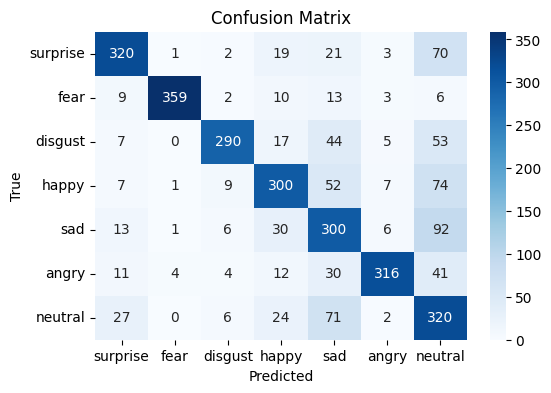

In [19]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_true, y_predDenseNet)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

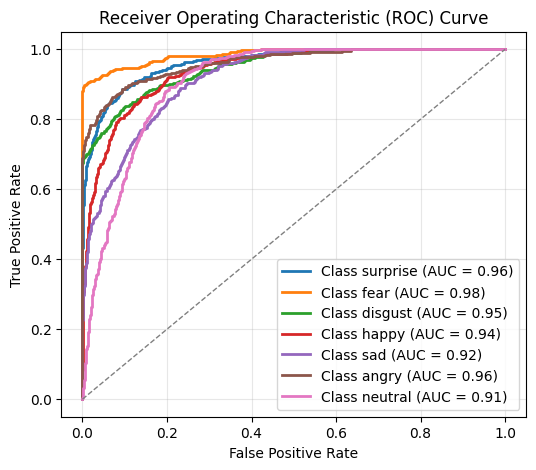

In [20]:
# Binarize the true labels for multi-class ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(len(classes))))

# Initialisation des FPR, TPR, et AUC pour chaque classe
fpr = {}
tpr = {}
roc_auc = {}

# Calcul des courbes ROC et de l'AUC pour chaque classe
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_predDenseNet_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracer toutes les courbes ROC
plt.figure(figsize=(6, 5))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Ligne de référence pour une prédiction aléatoire
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Personnalisation du graphique
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()